In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sklearn as sk
import pandas as pd
from scipy.stats import binned_statistic_2d
import seaborn as sns
import emcee
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from itertools import product
from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from mlxtend.plotting import plot_confusion_matrix

from joblib import dump, load

from pyROGER import roger
from pyROGER import models

from scipy import stats
import importlib
with importlib.resources.path("pyROGER", "dataset") as p:
    DATA_PATH = str(p)

/tmp/ipykernel_966430/2948299967.py:25: DeprecationWarning: path is deprecated. Use files() instead. Refer to https://importlib-resources.readthedocs.io/en/latest/using.html#migrating-from-legacy for migration advice.
  with importlib.resources.path("pyROGER", "dataset") as p:


In [129]:
models.list_saved_models()

['/home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/HighMassRoger1_KNN.joblib',
 '/home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/HighMassRoger1_SVM.joblib',
 '/home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/roger2_KNN.joblib',
 '/home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/HighMassRoger1_RF.joblib']

In [23]:
# ROGER1
data_R1 = pd.read_csv(DATA_PATH + '/highMass_trainset_roger1.csv', sep = ' ')
data_R1 = np.asarray(data_R1)

data_R1[np.where(data_R1[:,2] == 'CL')[0], 2] = 1
data_R1[np.where(data_R1[:,2] == 'BS')[0], 2] = 2
data_R1[np.where(data_R1[:,2] == 'RIN')[0], 2] = 3
data_R1[np.where(data_R1[:,2] == 'IN')[0], 2] = 4
data_R1[np.where(data_R1[:,2] == 'ITL')[0], 2] = 5
data_R1 = data_R1.astype('float64')

cl_R1  = data_R1[np.where(data_R1[:,2] == 1)[0]]
bs_R1  = data_R1[np.where(data_R1[:,2] == 2)[0]]
rin_R1 = data_R1[np.where(data_R1[:,2] == 3)[0]]
inf_R1 = data_R1[np.where(data_R1[:,2] == 4)[0]]
itl_R1 = data_R1[np.where(data_R1[:,2] == 5)[0]]

print('Hay ' + str(len(cl_R1) / len(data_R1)) + ' cluster galaxies')
print('Hay ' + str(len(bs_R1) / len(data_R1)) + ' backsplash galaxies')
print('Hay ' + str(len(rin_R1) / len(data_R1)) + ' recent infalling galaxies')
print('Hay ' + str(len(inf_R1) / len(data_R1)) + ' infalling galaxies')
print('Hay ' + str(len(itl_R1) / len(data_R1)) + ' interlooper galaxies')


Hay 0.12392870686386044 cluster galaxies
Hay 0.17167235494880545 backsplash galaxies
Hay 0.09984831247629883 recent infalling galaxies
Hay 0.2915813424345848 infalling galaxies
Hay 0.3129692832764505 interlooper galaxies


In [3]:
data_R1.shape

(26370, 3)

In [212]:
#ROGER2

data_train = np.loadtxt('../data/chuti_sorted.dat')

# data_train[:,0] 
# data_train[:,1] = Clase 
# data_train[:,2] = log(M/Msun) 
# data_train[:,3] = r/R200 
# data_train[:,4] = v/delta v 
# -

cl_ind = np.unique(data_train[:,0])
nclusters = len(cl_ind)
print('There are ' + str(nclusters) + ' clusters')

# +
ntrain = int(0.8 * nclusters)
ntest = ntrain#nclusters - ntrain

np.random.seed(91218)
random_ind = np.random.choice(cl_ind, replace = False, size = nclusters)

cl_train_ind = random_ind[:ntrain]
cl_test_ind = random_ind[ntrain:]

gal_train_ind = np.where(np.isin(data_train[:,0], cl_train_ind) == True)[0]
gal_test_ind = np.where(np.isin(data_train[:,0], cl_test_ind) == True)[0]

gal_test_ind = np.random.choice(gal_test_ind, size = 40000)
# -

cl_ind = np.where(data_train[:,1] == 1)[0] 
bs_ind = np.where(data_train[:,1] == 2)[0] 
rin_ind = np.where(data_train[:,1] == 3)[0] 
in_ind = np.where(data_train[:,1] == 4)[0] 
itl_ind = np.where(data_train[:,1] == 5)[0] 

print('Hay {:.2f} cluster galaxies'.format(len(cl_ind) / len(data_train)))
print('Hay {:.2f} backsplash galaxies'.format(len(bs_ind) / len(data_train)))
print('Hay {:.2f} recent infalling galaxies'.format(len(rin_ind) / len(data_train)))
print('Hay {:.2f} infalling galaxies'.format(len(in_ind) / len(data_train)))
print('Hay {:.2f} interloper galaxies'.format(len(itl_ind) / len(data_train)))

There are 33805 clusters
Hay 0.15 cluster galaxies
Hay 0.16 backsplash galaxies
Hay 0.09 recent infalling galaxies
Hay 0.26 infalling galaxies
Hay 0.34 interloper galaxies


In [5]:
Roger2 = roger.RogerModel(x_dataset = data_train[gal_train_ind, 2:], y_dataset = data_train[gal_train_ind, 1], 
                          ml_models = [KNeighborsClassifier(n_neighbors=63), RandomForestClassifier(max_depth=2, random_state=0)])

Roger2.train(path_to_saved_model = ['../data/models/roger2_KNN_tiny.joblib','../data/models/roger2_RF_tiny.joblib'])

Roger2.trained

Loading model from: ../data/models/roger2_KNN_tiny.joblib
Loading model from: ../data/models/roger2_RF_tiny.joblib


In [131]:
Roger1 = roger.RogerModel(x_dataset = data_train[gal_train_ind, 3:], y_dataset = data_train[gal_train_ind, 1], 
                          ml_models = [KNeighborsClassifier(n_neighbors=63)])

Roger1.train(path_to_saved_model = ['/home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/HighMassRoger1_KNN.joblib'])

Roger1.trained


Loading model from: /home/mdelosrios/trabajos/pyROGER/pyROGER/dataset/HighMassRoger1_KNN.joblib


/home/mdelosrios/trabajos/ROGER2/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


True

In [58]:
#TNG data
aux_TNG = pd.read_csv('../data/data_tng300_03_10_25.dat', sep="\t")
aux_TNG = np.asarray(aux_TNG)

data_TNG = np.copy(aux_TNG)

# Put the correct order needed for pyroger
data_TNG[:,2] = aux_TNG[:,3] # [:,2] need to be the class
data_TNG[:,3] = aux_TNG[:,2] # [:,3] need to be log mass
data_TNG[:,4] = aux_TNG[:,4] # [:,4] need to be r/r200
data_TNG[:,5] = aux_TNG[:,5] # [:,5] need to be v/sigma

# change class beacuse in pyroger class=2 is blacksplash
#ind = np.where(aux_TNG[:,3] == 2)
#data_TNG[ind,2] = 1

# change class beacuse in pyroger class=1 is cluster
#ind = np.where(aux_TNG[:,3] == 1)
#data_TNG[ind,2] = 2

data_TNG[:,3] = data_TNG[:,3]

# data_TNG[:,0] =  halo ID
# data_TNG[:,1] =  subhalo ID
# data_TNG[:,2] =  clasificacion real de la galaxia (CL = 1, BS = 2, RIN = 3, IN = 4, ITL = 5)
# data_TNG[:,3] = log masa del cumulo
# data_TNG[:,4] = rp/R200
# data_TNG[:,5] = |Delta V|/sigma
# -

# +
cl_TNG  = data_TNG[np.where(data_TNG[:,2] == 1)[0]]
bs_TNG  = data_TNG[np.where(data_TNG[:,2] == 2)[0]]
rin_TNG = data_TNG[np.where(data_TNG[:,2] == 3)[0]]
inf_TNG = data_TNG[np.where(data_TNG[:,2] == 4)[0]]
itl_TNG = data_TNG[np.where(data_TNG[:,2] == 5)[0]]

print('Hay ' + str(len(cl_TNG) / len(data_TNG)) + ' cluster galaxies')
print('Hay ' + str(len(rin_TNG) / len(data_TNG)) + ' recent infalling galaxies')
print('Hay ' + str(len(bs_TNG) / len(data_TNG)) + ' backsplash galaxies')
print('Hay ' + str(len(inf_TNG) / len(data_TNG)) + ' infalling galaxies')
print('Hay ' + str(len(itl_TNG) / len(data_TNG)) + ' interlooper galaxies')

Hay 0.36103028616248767 cluster galaxies
Hay 0.08255952230346887 recent infalling galaxies
Hay 0.1031298231409559 backsplash galaxies
Hay 0.2378868000910862 infalling galaxies
Hay 0.21539356830200138 interlooper galaxies


In [53]:
nbin = np.linspace(0,3,20)
r1_cl_stats = stats.binned_statistic_2d(cl_R1[:,0], cl_R1[:,1], None, 'count', bins=[nbin, nbin])
r1_bs_stats = stats.binned_statistic_2d(bs_R1[:,0], bs_R1[:,1], None, 'count', bins=[nbin, nbin])
r1_rin_stats = stats.binned_statistic_2d(rin_R1[:,0], rin_R1[:,1], None, 'count', bins=[nbin, nbin])
r1_inf_stats = stats.binned_statistic_2d(inf_R1[:,0], inf_R1[:,1], None, 'count', bins=[nbin, nbin])

In [75]:
np.mean(data_train, axis = 0)

array([1.08844482e+04, 3.46890793e+00, 1.40538308e+01, 1.45632655e+00,
       8.40305703e-01])

In [73]:
data_test.shape

(400, 3)

In [77]:
xcenters = 0.5 * (nbin[:-1] + nbin[1:])
ycenters = 0.5 * (nbin[:-1] + nbin[1:])

X, Y = np.meshgrid(xcenters, ycenters)

data_test = np.zeros((len(nbin) * len(nbin), 3))
c = 0
for i in xcenters:
    for j in ycenters:
        data_test[c,0] = 14
        data_test[c,1] = i
        data_test[c,2] = j
        c += 1

In [217]:
pred_prob_total = Roger2.predict_prob(data_train[gal_test_ind, 2:], n_model=0)
pred_class_total = Roger2.predict_class(data_train[gal_test_ind, 2:], n_model=0)


Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0


In [218]:
pred_prob_total.shape

(40000, 5)

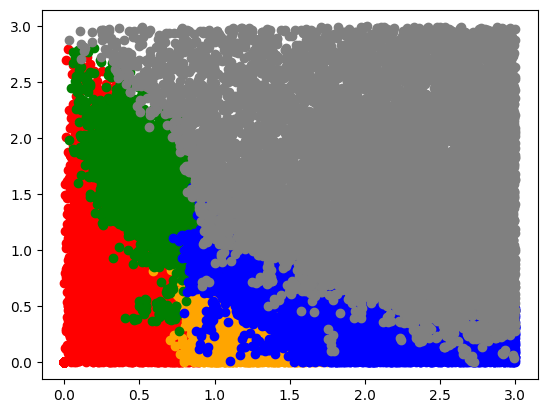

In [219]:
plt.scatter(data_train[gal_test_ind[np.where(pred_class_total == 1)[0]], 3], data_train[gal_test_ind[np.where(pred_class_total == 1)[0]], 4], color = 'red')
plt.scatter(data_train[gal_test_ind[np.where(pred_class_total == 2)[0]], 3], data_train[gal_test_ind[np.where(pred_class_total == 2)[0]], 4], color = 'orange')
plt.scatter(data_train[gal_test_ind[np.where(pred_class_total == 3)[0]], 3], data_train[gal_test_ind[np.where(pred_class_total == 3)[0]], 4], color = 'green')
plt.scatter(data_train[gal_test_ind[np.where(pred_class_total == 4)[0]], 3], data_train[gal_test_ind[np.where(pred_class_total == 4)[0]], 4], color = 'blue')
plt.scatter(data_train[gal_test_ind[np.where(pred_class_total == 5)[0]], 3], data_train[gal_test_ind[np.where(pred_class_total == 5)[0]], 4], color = 'gray')

In [133]:
pred_prob = Roger2.predict_prob(data_test, n_model=0)
pred_prob_r1 = Roger1.predict_prob(data_test[:,1:], n_model=0)

Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0


In [84]:
pred_prob.shape

(400, 5)

In [164]:
prob_cl_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob[:,0], 'mean', bins=[nbin, nbin])
prob_bs_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob[:,1], 'mean', bins=[nbin, nbin])
prob_rin_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob[:,2], 'mean', bins=[nbin, nbin])
prob_in_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob[:,3], 'mean', bins=[nbin, nbin])
prob_itl_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob[:,4], 'mean', bins=[nbin, nbin])

prob_cl_r1_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob_r1[:,0], 'mean', bins=[nbin, nbin])
prob_bs_r1_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob_r1[:,2], 'mean', bins=[nbin, nbin])
prob_rin_r1_stats = stats.binned_statistic_2d(data_test[:,1], data_test[:,2], pred_prob_r1[:,1], 'mean', bins=[nbin, nbin])

In [52]:
r2_cl_stats = stats.binned_statistic_2d(data_train[cl_ind,3], data_train[cl_ind,4], None, 'count', bins=[nbin, nbin])
r2_bs_stats = stats.binned_statistic_2d(data_train[bs_ind,3], data_train[bs_ind,4], None, 'count', bins=[nbin, nbin])
r2_rin_stats = stats.binned_statistic_2d(data_train[rin_ind,3], data_train[rin_ind,4], None, 'count', bins=[nbin, nbin])
r2_inf_stats = stats.binned_statistic_2d(data_train[in_ind,3], data_train[in_ind,4], None, 'count', bins=[nbin, nbin])
r2_itl_stats = stats.binned_statistic_2d(data_train[itl_ind,3], data_train[itl_ind,4], None, 'count', bins=[nbin, nbin])

In [61]:
tng_cl_stats = stats.binned_statistic_2d(cl_TNG[:,4], cl_TNG[:,5], None, 'count', bins=[nbin, nbin])
tng_bs_stats = stats.binned_statistic_2d(bs_TNG[:,4], bs_TNG[:,5], None, 'count', bins=[nbin, nbin])
tng_rin_stats = stats.binned_statistic_2d(rin_TNG[:,4], rin_TNG[:,5], None, 'count', bins=[nbin, nbin])
tng_inf_stats = stats.binned_statistic_2d(inf_TNG[:,4], inf_TNG[:,5], None, 'count', bins=[nbin, nbin])
tng_itl_stats = stats.binned_statistic_2d(itl_TNG[:,4], itl_TNG[:,5], None, 'count', bins=[nbin, nbin])

/tmp/ipykernel_966430/603085971.py:19: RuntimeWarning: invalid value encountered in divide
  ax[0,0].imshow(r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
/tmp/ipykernel_966430/603085971.py:20: RuntimeWarning: invalid value encountered in divide
  ax[0,0].contour(r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T), extent = (0,3,0,3), levels = [0,0.5,1], colors = 'magenta')
/tmp/ipykernel_966430/603085971.py:21: RuntimeWarning: invalid value encountered in divide
  ax[0,1].imshow(r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
/tmp/ipykernel_966430/603085971.py:22: RuntimeWarning: invalid value encountered in divide
  ax[0,1].contour(r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T), extent = (0,3,0,3), levels = [0,0.5,1], colors = 'magenta')
/tmp/ipykernel

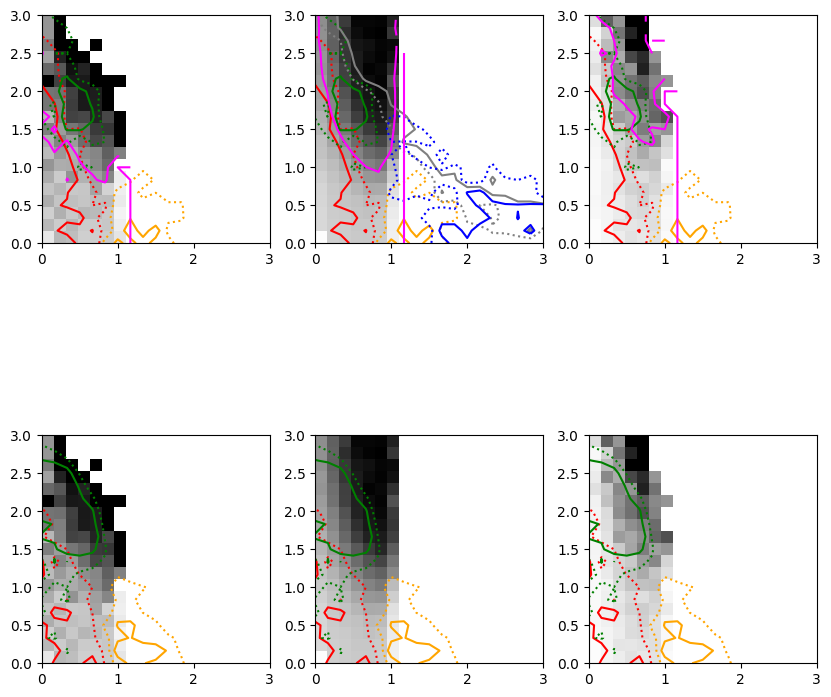

In [170]:
fig,ax = plt.subplots(2,3, figsize = (10,10))

ax[0,0].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])

ax[0,0].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])

ax[0,0].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])

ax[0,1].contour(prob_itl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','gray', 'gray'], linestyles = ['solid', ':', 'solid'])

ax[0,1].contour(prob_in_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','blue', 'blue'], linestyles = ['solid', ':', 'solid'])

ax[0,0].imshow(r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[0,0].contour(r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T), extent = (0,3,0,3), levels = [0,0.5,1], colors = 'magenta')
ax[0,1].imshow(r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[0,1].contour(r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T), extent = (0,3,0,3), levels = [0,0.5,1], colors = 'magenta')
ax[0,2].imshow(tng_rin_stats.statistic.T / (tng_cl_stats.statistic.T + tng_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[0,2].contour(tng_rin_stats.statistic.T / (tng_cl_stats.statistic.T + tng_rin_stats.statistic.T), extent = (0,3,0,3), levels = [0,0.5,1], colors = 'magenta')
#plt.colorbar()

ax[1,0].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])

ax[1,0].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])

ax[1,0].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])

ax[1,0].imshow(r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[1,1].imshow(r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[1,2].imshow(tng_rin_stats.statistic.T / (tng_cl_stats.statistic.T + tng_rin_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')

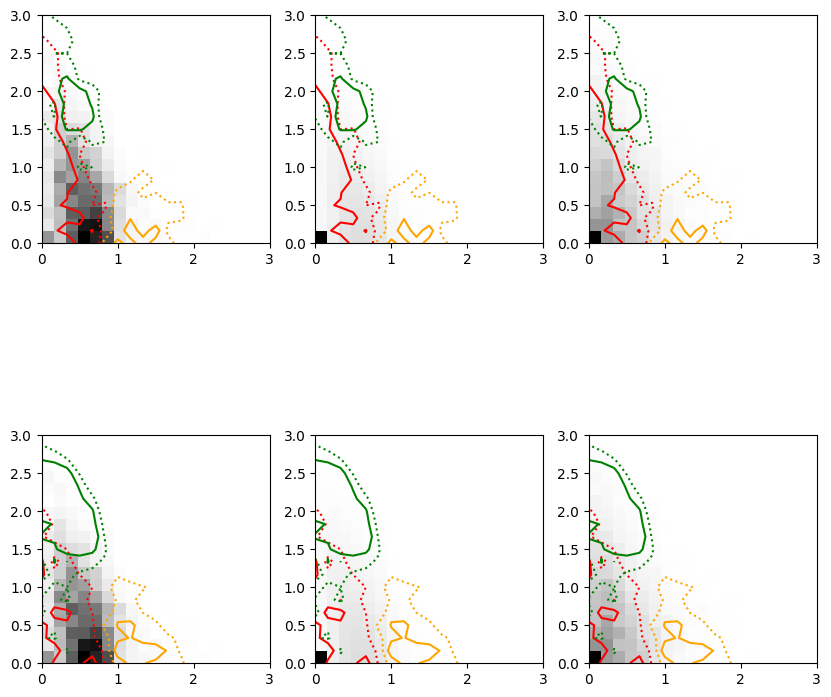

In [141]:
fig,ax = plt.subplots(2,3, figsize = (10,10))

ax[0,0].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])

ax[0,0].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_bs_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])

ax[0,0].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[0,1].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[0,2].contour(prob_rin_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])

ax[0,0].imshow(r1_cl_stats.statistic.T / np.sum(r1_cl_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[0,1].imshow(r2_cl_stats.statistic.T / np.sum(r2_cl_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[0,2].imshow(tng_cl_stats.statistic.T / np.sum(tng_cl_stats.statistic.T ), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
#plt.colorbar()

ax[1,0].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_cl_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','red', 'red'], linestyles = ['solid', ':', 'solid'])

ax[1,0].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_bs_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','orange', 'orange'], linestyles = ['solid', ':', 'solid'])

ax[1,0].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[1,1].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])
ax[1,2].contour(prob_rin_r1_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','green', 'green'], linestyles = ['solid', ':', 'solid'])

ax[1,0].imshow(r1_cl_stats.statistic.T / np.sum(r1_cl_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[1,1].imshow(r2_cl_stats.statistic.T / np.sum(r2_cl_stats.statistic.T), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
ax[1,2].imshow(tng_cl_stats.statistic.T / np.sum(tng_cl_stats.statistic.T ), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')

/tmp/ipykernel_966430/2918140986.py:1: RuntimeWarning: invalid value encountered in divide
  aux_r1 = r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T)
/tmp/ipykernel_966430/2918140986.py:2: RuntimeWarning: invalid value encountered in divide
  aux_r2 = r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T)
/tmp/ipykernel_966430/2918140986.py:3: RuntimeWarning: invalid value encountered in divide
  aux_tng = tng_rin_stats.statistic.T / (tng_cl_stats.statistic.T + tng_rin_stats.statistic.T)


Text(0.5, 0, 'roger2 set')

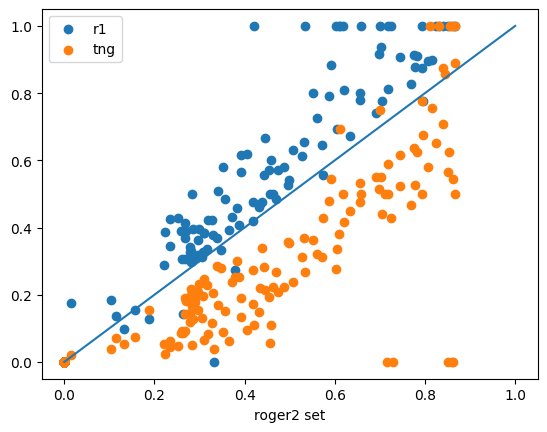

In [67]:
aux_r1 = r1_rin_stats.statistic.T / (r1_cl_stats.statistic.T + r1_rin_stats.statistic.T)
aux_r2 = r2_rin_stats.statistic.T / (r2_cl_stats.statistic.T + r2_rin_stats.statistic.T)
aux_tng = tng_rin_stats.statistic.T / (tng_cl_stats.statistic.T + tng_rin_stats.statistic.T)

plt.scatter(aux_r2.flatten(), aux_r1.flatten(), label = 'r1')
plt.scatter(aux_r2.flatten(), aux_tng.flatten(), label = 'tng')
plt.legend()
plt.plot([0,1], [0,1])
plt.xlabel('roger2 set')

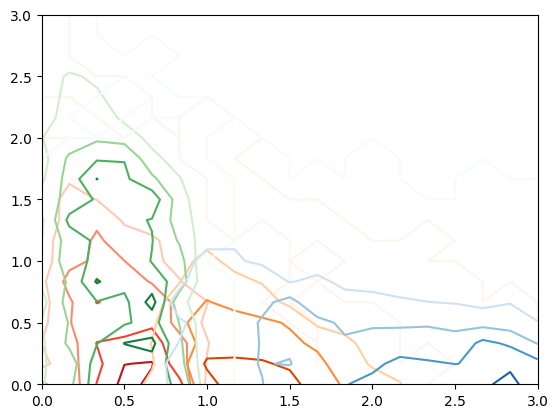

In [42]:
#plt.imshow(ret_cl.statistic.T / len(data_R1), extent = (0,3,0,3), origin = 'lower', cmap = 'Grays')
plt.contour(ret_cl.statistic.T / len(data_R1), extent = (0,3,0,3), cmap = 'Reds', levels = 4)
plt.contour(ret_bs.statistic.T / len(data_R1), extent = (0,3,0,3), cmap = 'Oranges', levels = 4)
plt.contour(ret_rin.statistic.T / len(data_R1), extent = (0,3,0,3), cmap = 'Greens', levels = 4)
plt.contour(ret_inf.statistic.T / len(data_R1), extent = (0,3,0,3), cmap = 'Blues', levels = 4)
#plt.imshow(ret_bs.statistic.T, extent = (0,3,0,3), origin = 'lower')

In [172]:
tng_probs = np.loadtxt('../data/ROGER2_KNN_probabilities_testset_TNG_03_10_25.txt', skiprows = 18)

'''
         ID_cl: Cluster ID.
         ID_sub: Subhalo ID.
         class: Real class.
         LogM: Log10 of the cluster mass.
         R/R200: Galaxy radial distance to the cluster center, normalized to R200.
         V/sigma: Galaxy relative velocity to cluster center normalized to cluster velocity dispersion.
         P_cl: Probability of being a cluster galaxy.
         P_bs: Probability of being a backsplash galaxy.
         P_rin: Probability of being a recent infaller galaxy.
         P_in: Probability of being an infalling galaxy.
         P_itl: Probability of being a iterloper galaxy.
'''

In [173]:
cl_cl = np.where((tng_probs[:,2] == 1) & (tng_probs[:,6] > 0.5))[0]
cl_bs = np.where((tng_probs[:,2] == 1) & (tng_probs[:,7] > 0.5))[0]
cl_rin = np.where((tng_probs[:,2] == 1) & (tng_probs[:,8] > 0.5))[0]
cl_in = np.where((tng_probs[:,2] == 1) & (tng_probs[:,9] > 0.5))[0]
cl_itl = np.where((tng_probs[:,2] == 1) & (tng_probs[:,10] > 0.5))[0]

bs_cl = np.where((tng_probs[:,2] == 2) & (tng_probs[:,6] > 0.5))[0]
bs_bs = np.where((tng_probs[:,2] == 2) & (tng_probs[:,7] > 0.5))[0]
bs_rin = np.where((tng_probs[:,2] == 2) & (tng_probs[:,8] > 0.5))[0]
bs_in = np.where((tng_probs[:,2] == 2) & (tng_probs[:,9] > 0.5))[0]
bs_itl = np.where((tng_probs[:,2] == 2) & (tng_probs[:,10] > 0.5))[0]

rin_cl = np.where((tng_probs[:,2] == 3) & (tng_probs[:,6] > 0.5))[0]
rin_bs = np.where((tng_probs[:,2] == 3) & (tng_probs[:,7] > 0.5))[0]
rin_rin = np.where((tng_probs[:,2] == 3) & (tng_probs[:,8] > 0.5))[0]
rin_in = np.where((tng_probs[:,2] == 3) & (tng_probs[:,9] > 0.5))[0]
rin_itl = np.where((tng_probs[:,2] == 3) & (tng_probs[:,10] > 0.5))[0]

In [209]:
tng_probs.shape

(39523, 11)

Text(1, 0.3, 'Pred ITL')

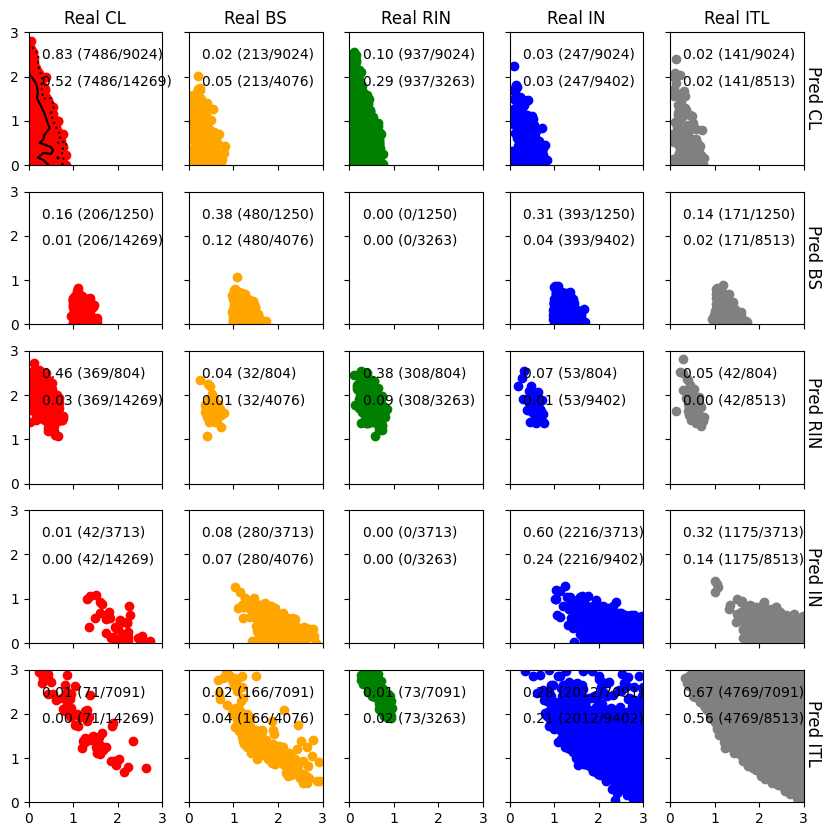

In [227]:
fig, axes = plt.subplots(5,5, sharex = True, sharey = True, figsize = (10,10))

colors = ['red','orange','green','blue','gray']

for i in range(5):
    for j in range(5):
        ax = axes[i,j]
        
        aux_ind = np.where((tng_probs[:,2] == (j+1)) & (tng_probs[:,(i+6)] > 0.5))[0]
        ax.scatter(tng_probs[aux_ind][:,4], tng_probs[aux_ind][:,5], color = colors[j])

        purity = len(aux_ind) / len(np.where(tng_probs[:,(i+6)] > 0.5)[0]) # Cuantas hay de una clase real j del total predicho como de una clase i
        sens = len(aux_ind) / len(np.where(tng_probs[:,2] == (j+1))[0]) # Cuantas hay predichas como j de las que son en realidad i

        ax.text(0.1,0.8, '{:.2f} ({}/{})'.format(purity,len(aux_ind),len(np.where(tng_probs[:,(i+6)] > 0.5)[0])), transform = ax.transAxes)
        ax.text(0.1,0.6, '{:.2f} ({}/{})'.format(sens,len(aux_ind),len(np.where(tng_probs[:,2] == (j+1))[0])), transform = ax.transAxes)
        
        #ax.text(0.5,0.8, 'Pur {:.2f}'.format(purity), transform = ax.transAxes)
        #ax.text(0.5,0.6, 'Sens {:.2f}'.format(sens), transform = ax.transAxes)

axes[0,0].contour(prob_cl_stats.statistic.T, levels = [-0.1,0.35,0.5,1], extent = (0,3,0,3), colors = ['white','black', 'black'], linestyles = ['solid', ':', 'solid'])

ax.set_xlim(0,3)
ax.set_ylim(0,3)

axes[0,0].set_title('Real CL')
axes[0,1].set_title('Real BS')
axes[0,2].set_title('Real RIN')
axes[0,3].set_title('Real IN')
axes[0,4].set_title('Real ITL')

axes[0,4].text(1,0.3,'Pred CL', transform = axes[0,4].transAxes, rotation = -90, fontsize = 12)
axes[1,4].text(1,0.3,'Pred BS', transform = axes[1,4].transAxes, rotation = -90, fontsize = 12)
axes[2,4].text(1,0.3,'Pred RIN', transform = axes[2,4].transAxes, rotation = -90, fontsize = 12)
axes[3,4].text(1,0.3,'Pred IN', transform = axes[3,4].transAxes, rotation = -90, fontsize = 12)
axes[4,4].text(1,0.3,'Pred ITL', transform = axes[4,4].transAxes, rotation = -90, fontsize = 12)

In [207]:
data_train[gal_test_ind, :].shape

(10000, 5)

Text(1, 0.3, 'Pred ITL')

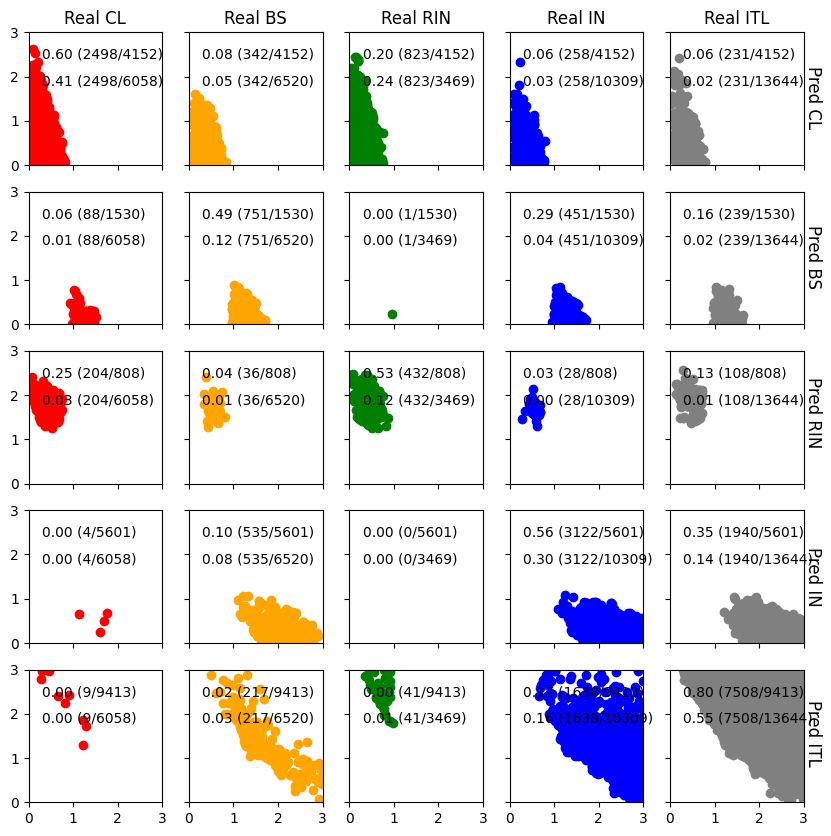

In [229]:
fig, axes = plt.subplots(5,5, sharex = True, sharey = True, figsize = (10,10))

colors = ['red','orange','green','blue','gray']

for i in range(5):
    for j in range(5):
        ax = axes[i,j]
        
        aux_ind = np.where((data_train[gal_test_ind, 1] == (j+1)) & (pred_prob_total[:,(i)] > 0.5))[0]
        ax.scatter(data_train[gal_test_ind[aux_ind], 3], data_train[gal_test_ind[aux_ind], 4], color = colors[j])

        purity = len(aux_ind) / len(np.where(pred_prob_total[:,(i)] > 0.5)[0]) # Cuantas hay de una clase real j del total predicho como de una clase i
        sens = len(aux_ind) / len(np.where(data_train[gal_test_ind, 1] == (j+1))[0]) # Cuantas hay predichas como j de las que son en realidad i
        
        ax.text(0.1,0.8, '{:.2f} ({}/{})'.format(purity,len(aux_ind),len(np.where(pred_prob_total[:,(i)] > 0.5)[0])), transform = ax.transAxes)
        ax.text(0.1,0.6, '{:.2f} ({}/{})'.format(sens,len(aux_ind),len(np.where(data_train[gal_test_ind, 1] == (j+1))[0])), transform = ax.transAxes)
        
        #ax.text(0.5,0.8, 'Pur {:.2f}'.format(purity), transform = ax.transAxes)
        #ax.text(0.5,0.6, 'Sens {:.2f}'.format(sens), transform = ax.transAxes)

ax.set_xlim(0,3)
ax.set_ylim(0,3)

axes[0,0].set_title('Real CL')
axes[0,1].set_title('Real BS')
axes[0,2].set_title('Real RIN')
axes[0,3].set_title('Real IN')
axes[0,4].set_title('Real ITL')

axes[0,4].text(1,0.3,'Pred CL', transform = axes[0,4].transAxes, rotation = -90, fontsize = 12)
axes[1,4].text(1,0.3,'Pred BS', transform = axes[1,4].transAxes, rotation = -90, fontsize = 12)
axes[2,4].text(1,0.3,'Pred RIN', transform = axes[2,4].transAxes, rotation = -90, fontsize = 12)
axes[3,4].text(1,0.3,'Pred IN', transform = axes[3,4].transAxes, rotation = -90, fontsize = 12)
axes[4,4].text(1,0.3,'Pred ITL', transform = axes[4,4].transAxes, rotation = -90, fontsize = 12)